## <span style="color:blue"> Lezione 7 </span>



In [74]:

import matplotlib.pyplot as plt
import numpy as np




Per un sistema di $n=108$ particelle e condizioni periodiche al contorno soggette al potenziale di Lennard-Jones rappresentante un liquido 
con temperatura $T=1.1$, densità $\rho=0.8$ si ricavano stime delle seguenti quantità: 
- energia potenziale per particella
- pressione
- funzione di distribuzione radiale  $g(r)$

tramite due tipi di simulazione
- dinamica molecolare (MD) con l'algoritmo di Verlet 
- Monte Carlo (MC) con l'algoritmo di Metropolis (ensamble canonico)


### <span style="color:DodgerBlue"> Esercizio 7.2 </span>



Prima di effettuare le simulazioni, è necessario valutare due fenomeni. Innanzitutto, le simulazioni, sia dinamica molecolare (MD) con l'algoritmo di Verlet, sia Monte Carlo (MC) con l'algoritmo di Metropolis, intercorrono una fase di equilibrazione. Per valutarla, sono state eseguite le simulazioni con $10000$ blocchi e $1$ passo per blocco, e si sono stampati i dati di energia potenziale e temperatura (solo per MD), che vengono caricati nella cella sottostante. 

In [75]:
n_MD,MD_pot_en=np.loadtxt("l_07_all_es/equilibrazione/MD_potential_energy.dat",usecols=(0,1),unpack=True)
n_MC,MC_pot_en=np.loadtxt("l_07_all_es/equilibrazione/MC_potential_energy.dat",usecols=(0,1),unpack=True)
temp=np.loadtxt("l_07_all_es/equilibrazione/MD_temperature.dat",usecols=1)


Nella cella sottostante, invece, è riportato il codice che genera due grafici: il primo mette a confronto l'energia potenziale del blocco (e quindi istantanea) per MC e MD in funzione del numero di blocchi (e quindi di step), il secondo mostra invece la temperatura, sempre istantanea, di MD in funzione del numero di blocchi (siccome nella fase di equilibrazione di MD la temperatura si abbassa, per effettuare una simulazione ad una temperatura di $1.1$ bisogna partire da una temperatura più alta ( $2.0$)). 

Text(0, 0.5, '$T$')

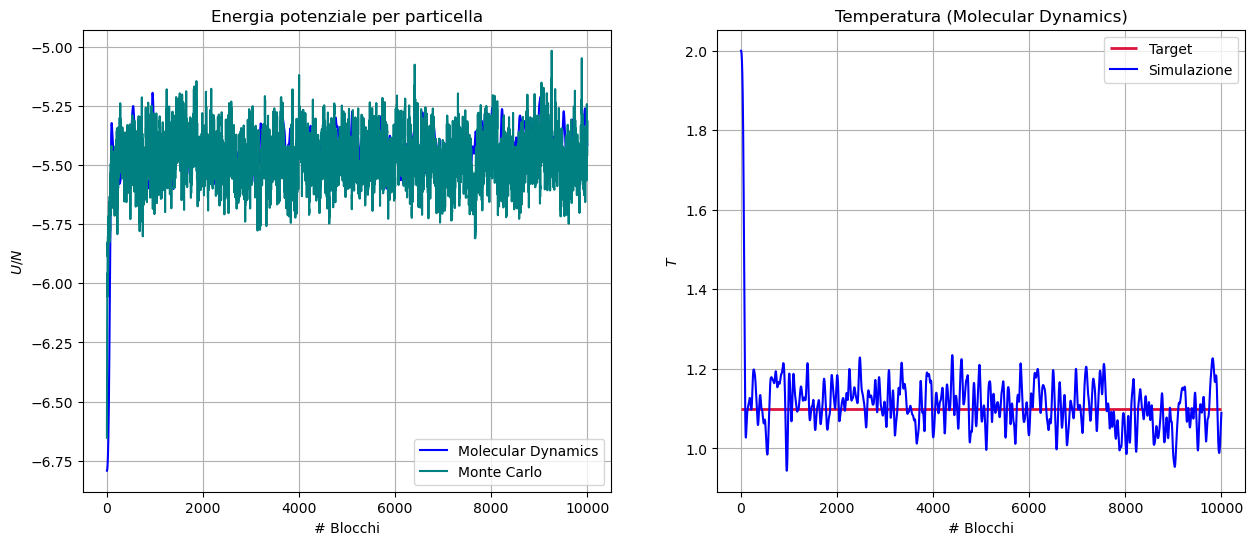

In [76]:

fig,axs=plt.subplots(1,2,figsize=[15,6])

axs[0].errorbar(n_MD,MD_pot_en,label="Molecular Dynamics",color="blue")
axs[0].errorbar(n_MC,MC_pot_en,label="Monte Carlo",color="teal")
axs[0].legend()
axs[0].set_title("Energia potenziale per particella")
axs[0].grid()
axs[0].set_xlabel("# Blocchi")
axs[0].set_ylabel(r"$U/N$")



axs[1].errorbar(n_MD,temp,color="blue", label="Simulazione")
axs[1].hlines(1.1,0,n_MD.max(),label="Target",color="crimson",linewidth=2)
axs[1].legend()
axs[1].grid()
axs[1].set_title("Temperatura (Molecular Dynamics)")
axs[1].set_xlabel("# Blocchi")
axs[1].set_ylabel(r"$T$")





Le quantità in esame si trovano molto rapidamente ad oscillare attorno al valor medio. E' evidente,quindi, che, aggiungendo nel main 5000 step di evoluzione "a vuoto" (senza effettuare alcuna misura) il requisito per l'equilibrazione è comodamente soddisfatto. 

Il secondo fenomeno da valutare è la correlazione tra configurazioni contigue, sia per MD che per MC. Ciò viene fatto eseguendo una simulazione per ciascun tipo, con $500000$ blocchi e $1$ step per blocco. (nota: il main è già stato modificato per aggiungere la fase di equilibrazione). I dati dell'energia potenziale del blocco delle simulazioni MD e MC vengono caricati nella cella sottostante. 

In [77]:
M=500000
MD_pot_en_=np.loadtxt("l_07_all_es/500000_step/MD_potential_energy.dat",usecols=1)
MC_pot_en_=np.loadtxt("l_07_all_es/500000_step/MC_potential_energy.dat",usecols=1)

### Es 7.2.1


Data una variabile $X$ misurata a step di lunghezza uniforme fino ad un massimo di $M$;  l'autocorrelazione al passo, o tempo, $m$ 
(ossia quanto la variabile sia correlata con sè stessa separata da $m$ passi) è, per $M \gg m$ : $$
R_{XX}(m)=\frac{\frac{1}{M-m} \sum_{i=0}^{M-m} \langle X(i) X(i+m) \rangle - 
\frac{1}{(M-m)^2} \left( \sum_{i=0}^{M-m} \langle X(i) \rangle\right) \left( \sum_{i=0}^{M-m} \langle X(i+m)\rangle \right) } 
 {\frac{1}{M}\sum_{i=0}^M X(i)^2 - \left(\frac{1}{M} \sum_{i=0}^M X(i) \right)^2}$$



La funzione è implementata nella cella sottostante. 

In [78]:
def autocorr_num(x,m,M): #calcola il numeratore dell'autocorrelazione al blocco m
    x_start=x[:M-m]
    x_end=x[m:]
    norm=1/(M-m)
    sum1=0
    sum1 = np.dot(x_start,x_end)
    sum2=x_start.sum()
    sum3=x_end.sum()


    return norm*(sum1 -norm*sum2*sum3)


def calc_autocorr(x,m_val,M): 
    den=x.var() # per tutti gli m il denominatore è la varianza dei dati
    corr=np.zeros(m_val.shape)
    for i,m in enumerate(m_val): 
        corr[i]=autocorr_num(x,int(m),M)


    return corr/den






La cella sottostante calcola l'autocorrelazione per un numero di passi $m$ compreso tra $1$ e $5000$. La cella ancora dopo crea i grafici dell'autocorrelazione in funzione del numero di passi per MC e MD. 

In [79]:

m_val=np.arange(1,5001)
MD_autocorr=calc_autocorr(MD_pot_en_,m_val,M)
MC_autocorr=calc_autocorr(MC_pot_en_,m_val,M)


Text(0.5, 0.98, "Autocorrelazione dell'energia potenziale per particella ($v$) all'aumentare del numero di step ($m$)")

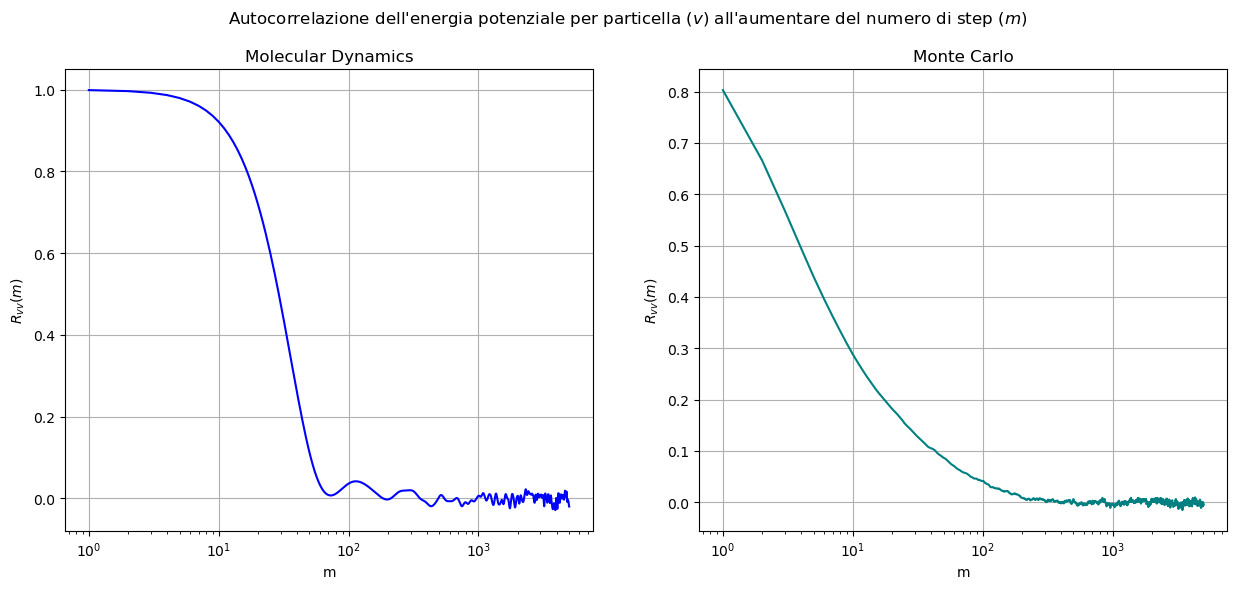

In [80]:
fig,axs=plt.subplots(1,2,figsize=[15,6])


axs[0].plot(m_val,MD_autocorr, color="blue")

axs[0].set_xlabel("m")
axs[0].set_ylabel(r"$R_{vv}(m)$")
axs[0].grid()
axs[0].semilogx()
axs[0].set_title("Molecular Dynamics")
axs[1].plot(m_val,MC_autocorr,color="teal")
axs[1].set_xlabel("m")
axs[1].set_ylabel(r"$R_{vv}(m)$")
axs[1].grid()
axs[1].semilogx()
axs[1].set_title("Monte Carlo")
fig.suptitle(r"Autocorrelazione dell'energia potenziale per particella ($v$) all'aumentare del numero di step ($m$)")







### Es 7.2.2


L'obiettivo è studiare l'impatto del data blocking sul calcolo dell'incertezza. Per farlo, si suddividono i $500000$ dati in blocchi di lunghezza $L$ crescente nell'intevallo $[10,5000]$. I valori di $L$ considerati sono i divisori esatti di $500000$ che cadono nell'intervallo scelto, trovati dal codice implementato nella cella sottostante. 

In [81]:
L=[]

for i in range(0,5):
    for j in range(0,6): 
        num=2**i*5**j
        if num <=5000 and num>=10: 
            L.append(num)


L=np.array(L)
L=np.sort(L)


La cella sottostante implementa il calcolo della deviazione standard per ogni lunghezza $L$ e il corrispettivo numero di blocchi $N$.

In [82]:
N=M/L
N=N.astype(int)
MD_error=np.zeros(L.shape)
MC_error=np.zeros(L.shape)


for i,shape in enumerate(zip(N,L)):

    blk_mean=np.mean(MD_pot_en_.reshape(shape),axis=1)#riorganizzati i dati in N righe e L colonne, media ogni riga
    err=np.sqrt(((np.dot(blk_mean,blk_mean))/N[i]- blk_mean.mean()**2)/N[i])
    MD_error[i]=err

    blk_mean=np.mean(MC_pot_en_.reshape(shape),axis=1)
    err=np.sqrt(((np.dot(blk_mean,blk_mean))/N[i]- blk_mean.mean()**2)/N[i])
    MC_error[i]=err

Text(0.5, 0.98, 'Valore della deviazione standard ottenuta con data blocking al variare della lunghezza dei blocchi ($L$)')

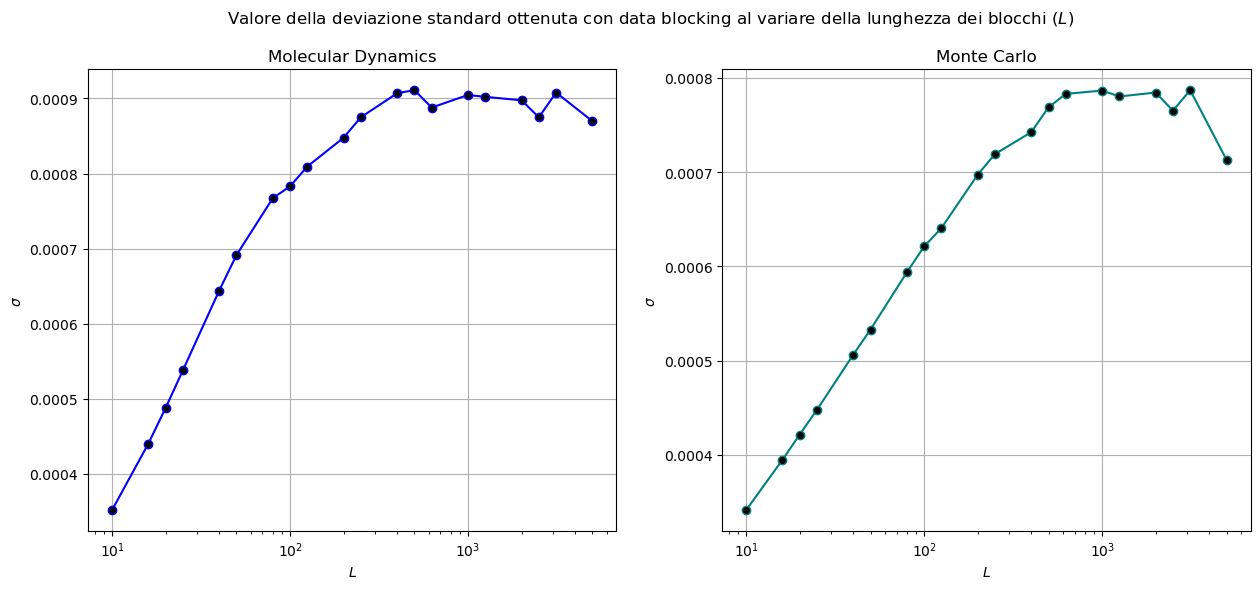

In [83]:
fig,axs=plt.subplots(1,2,figsize=[15,6])


axs[0].plot(L,MD_error,"-o",color="blue",mfc="black")
axs[0].set_xlabel(r"$L$")
axs[0].set_ylabel(r"$\sigma$")
axs[0].grid()
axs[0].semilogx()
axs[0].set_title("Molecular Dynamics")
axs[1].plot(L,MC_error,"-o",color="teal",mfc="black")
axs[1].set_xlabel(r"$L$")
axs[1].set_ylabel(r"$\sigma$")
axs[1].grid()
axs[1].semilogx()
axs[1].set_title("Monte Carlo")
fig.suptitle(r"Valore della deviazione standard ottenuta con data blocking al variare della lunghezza dei blocchi ($L$)")



La deviazione standard calcolata tramite data blocking cresce all'aumentare della grandezza dei blocchi. Da un certo valore di $L$ in poi la deviazione standard si assesta attorno ad un certo valore costante. Si nota che valore di $L$ necessario perchè ciò avvenga è comparabile col valore di $m$ dal quale la correlazione può essere considerata trascurabile. Ciò non è una sorpresa: è infatti lo scopo stesso del data blocking gestire l'autocorrelazione. D'ora in avanti,dunque, si prenderanno blocchi da $L=1000$ step ciascuno.

### <span style="color:DodgerBlue"> Esercizio 7.4 </span>



In [84]:
n,MD_pot_en,MD_pot_en_err=np.loadtxt("l_07_all_es/OUTPUT_MD/potential_energy.dat",usecols=(0,2,3),unpack=True)
MC_pot_en,MC_pot_en_err=np.loadtxt("l_07_all_es/OUTPUT_MC/potential_energy.dat",usecols=(2,3),unpack=True)
MD_pressure,MD_pressure_err=np.loadtxt("l_07_all_es/OUTPUT_MD/pressure.dat",usecols=(2,3),unpack=True)
MC_pressure,MC_pressure_err=np.loadtxt("l_07_all_es/OUTPUT_MC/pressure.dat",usecols=(2,3),unpack=True)
bins,MD_gofr,MD_gofr_err=np.loadtxt("l_07_all_es/OUTPUT_MD/gofr.dat",usecols=(0,1,2),unpack=True)
MC_gofr,MC_gofr_err=np.loadtxt("l_07_all_es/OUTPUT_MC/gofr.dat",usecols=(1,2),unpack=True)


bin_size=bins[1]



###  $g(r)$

Sia dato un sitema a $N$ particelle con una distribuzione di probabilità congiunta $p(r_1,...r_n)$ 
Si definisce  densità a $n$ particelle  $ \rho_N^n(r_1,...,r_n)= N!(N-n)!\int \mathrm{d} r_{n+1}... \mathrm{d} r_{N} p(r_1,...,r_n)$ e
distribuzione a $n$ particelle $$ g^n(r_1,...,r_n)= \frac{\rho_N^n(r_1,...,r_n)}{\prod_{i=1}^n \rho_N^1(r_i)} $$

La funzione di distribuzione radiale $g(r)$ è la distribuzione a $2$ particelle per un sistema omogeneo: $$ g_N^2(r_1,r_2)=g_N^2(|r_1-r_2|)=g(r)$

Il suo valore medio è dato da: $$ \langle g(r) \rangle = 1/(\rho N \Delta V) \langle 2 \sum_{i=1}^N \sum_{ j > i}^N \delta(|r| - |r_i-r_j|)\rangle $$ 


dove $\Delta V= 4/3 \pi ((r + dr)^3 - r^3)$. 

Operativamente, si costruisce un istogramma dove $dr$ è la grandezza dei bins e $r$ il bordo sinistro. Si cicla sulle coppie di particelle, si calcola la loro distanza $d$ e si aumenta di $2$ il conteggio del bin per cui $r \le d \le r+ dr$. Al termine, si normalizza con la quantità indicata. Per la simulazione è stato scelto un numero di bins pari a $100$. Nella cella sottostante sono graficati i risultati.

Text(0.5, 0, '$r$')

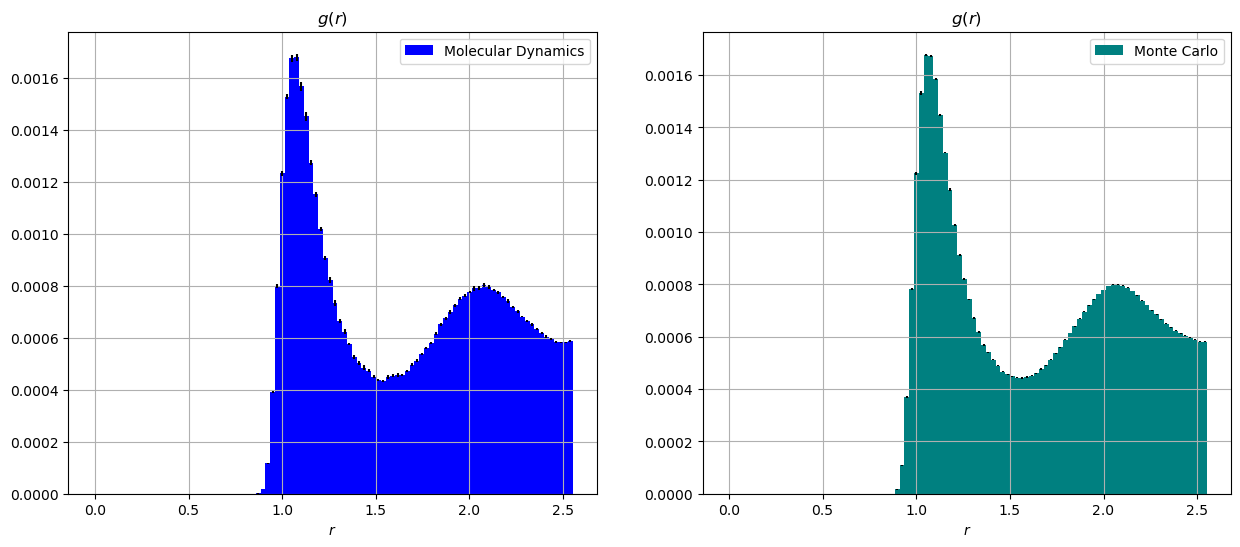

In [85]:


fig,axs=plt.subplots(1,2,figsize=[15,6])

axs[0].bar(bins,MD_gofr,yerr=MD_gofr_err,label="Molecular Dynamics",color="blue",width=bin_size)

axs[0].legend()
axs[0].set_title(r"$g(r)$")
axs[0].grid()
axs[0].set_xlabel(r"$r$")


axs[1].bar(bins,MC_gofr,yerr=MC_gofr_err,label="Monte Carlo",color="teal",width=bin_size)

axs[1].legend()
axs[1].set_title(r"$g(r)$")
axs[1].grid()
axs[1].set_xlabel(r"$r$")







### Energia potenziale

Text(0, 0.5, '$U/N$')

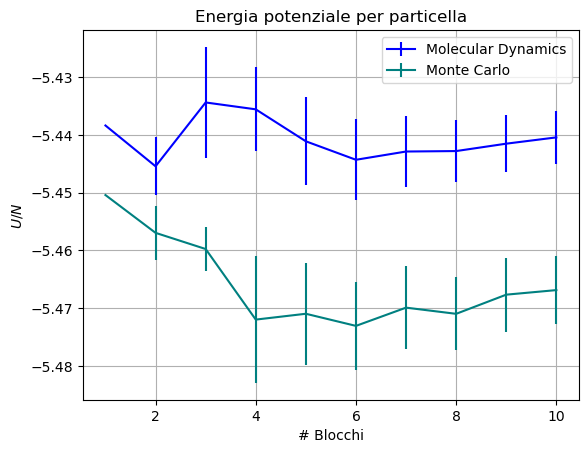

In [86]:
fig,ax=plt.subplots(1,1)

ax.errorbar(n,MD_pot_en,MD_pot_en_err,label="Molecular Dynamics",color="blue")
ax.errorbar(n,MC_pot_en,MC_pot_en_err,label="Monte Carlo",color="teal")
ax.legend()
ax.set_title("Energia potenziale per particella")
ax.grid()
ax.set_xlabel("# Blocchi")
ax.set_ylabel(r"$U/N$")







### Pressione

Text(0, 0.5, '$P$')

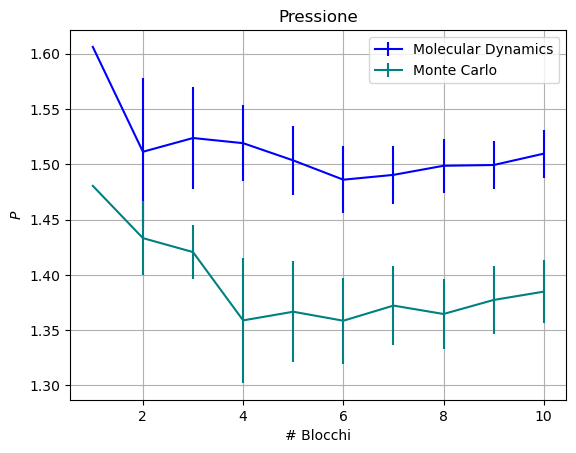

In [87]:
fig,ax=plt.subplots(1,1)

ax.errorbar(n,MD_pressure,MD_pressure_err,label="Molecular Dynamics",color="blue")
ax.errorbar(n,MC_pressure,MC_pressure_err,label="Monte Carlo",color="teal")
ax.legend()
ax.set_title("Pressione")
ax.grid()
ax.set_xlabel("# Blocchi")
ax.set_ylabel(r"$P$")

